# Scientific Computing Project #2

---------------

**Author:** *Salvador Palma* (mtr765) <br>
**Institution:** UCPH - University of Copenhagen

In [40]:
import numpy as np
from project1_linalg import householder_QR_slow, back_substitute, least_squares, infNorm

Kmat = np.load("Chladni-Kmat.npy")

In [23]:
print(Kmat.shape) #(15,15)

print(f"Singular? { np.linalg.det(Kmat) == 0}")
print(f"Symmetric? {np.allclose(Kmat, Kmat.T)}") 
print(f"Hermitian? {np.allclose(Kmat, Kmat.conj().T)}")
print(f"All real? {np.isreal(Kmat).all()}") 


(15, 15)
Singular? False
Symmetric? False
Hermitian? False
All real? True


In [43]:
from Project2_examplematrices import A1, A2, A3, A4, A5, A6, eigvals1, eigvals2, eigvals3, eigvals4, eigvals5, eigvals6

test_matrices = [A1, A2, A3, A4, A5, A6]
test_eigenvalues = [eigvals1, eigvals2, eigvals3, eigvals4, eigvals5, eigvals6]

for i, A in enumerate(test_matrices):
    print(f"Matrix {i+1}:")
    print(f"Size: {A.shape}")
    print(f"Singular? { np.linalg.det(A) == 0}")
    print(f"Symmetric? {np.allclose(A, A.T)}") 
    print(f"Hermitian? {np.allclose(A, A.conj().T)}")
    print(f"All real? {np.isreal(A).all()}") 
    print()

Matrix 1:
Size: (2, 2)
Singular? False
Symmetric? True
Hermitian? True
All real? True

Matrix 2:
Size: (2, 2)
Singular? False
Symmetric? True
Hermitian? True
All real? True

Matrix 3:
Size: (3, 3)
Singular? False
Symmetric? False
Hermitian? False
All real? True

Matrix 4:
Size: (3, 3)
Singular? True
Symmetric? False
Hermitian? False
All real? True

Matrix 5:
Size: (5, 5)
Singular? True
Symmetric? False
Hermitian? False
All real? True

Matrix 6:
Size: (5, 5)
Singular? False
Symmetric? True
Hermitian? True
All real? True



## Week #3

### Exercise a)

#### (1)

Simplifying the teachings of Gershgorin's Theorem, we can approximate the eigenvalues $\lambda$ of a matrix $A$ by instead computing circles (a center and a radius) from which an eigenvalue shall lie within. The formula for finding this bound for an eigenvector is the following:

$$center_k = A_{kk}$$
$$radius_k = \sum\limits_{j \neq k} A_{kj}$$

Essentially, per row, the center is the diagonal entry, and the radius the sum of the rest of the row. The code implementation is very straightforward, and is done in the cell below through the function `gershgorin(A)`

In [12]:
import numpy as np
def gershgorin(A):
    n = A.shape[0]
    centers = np.zeros(n)
    radii = np.zeros(n)
    for k in range(n):
        centers[k] = A[k, k]
        radii[k] = np.sum(np.abs(A[k, :])) - np.abs(A[k, k])
        
    return centers, radii

#### (2)

Using the previous algorithm on matrix `Kmat` we can localize the 15 eigenvalues within bounds. Which are more appropriately displayed, rounded to three decimal cases, in the table below


| $k$ | Center | Radius |
| --- | --- | --- |
| 1 |129292.219 | 42231.647|
| 2 |103041.439 | 56927.519|
| 3 |64967.579 |31160.671 |
| 4 |43612.412 |18532.349 |
| 5 | 36273.752|7870.516 |
| 6 | 37990.099|17854.703 |
| 7 | 24166.971|15414.717 |
| 8 |11651.159 |2512.041 |
| 9 | 13865.080|5502.970 |
| 10 |5600.548 | 1195.283|
| 11 |1173.039 |341.990 |
| 12 |1760.771 |401.215 |
| 13 | 288.423|71.417 |
| 14 | 86.897|2.540 |
| 15 | 13.893|0.259 |

To properly bound these eigenvalues, we still need to take into consideration that they can be complex numbers. With the quick analysis and console output of the initial cells in the document, we know that `Kmat` is not singular, non-symetric, non-hermitian, and belongs to $\mathbb{R}^{15 \times 15}$. Meaning that, even though the centers do belong to $\mathbb{R}$, the eigenvalues do not necessarily.

In [16]:
centersK, radiiK = gershgorin(Kmat)

print("Gershgorin Circles for K:")
for i in range(len(centersK)):
    print(f"Circle {i+1}: Center = {centersK[i]:.3f}, Radius = {radiiK[i]:.3f}")

Gershgorin Circles for K:
Circle 1: Center = 129292.219, Radius = 42231.647
Circle 2: Center = 103041.439, Radius = 56927.519
Circle 3: Center = 64967.579, Radius = 31160.671
Circle 4: Center = 43612.412, Radius = 18532.349
Circle 5: Center = 36273.752, Radius = 7870.516
Circle 6: Center = 37990.099, Radius = 17854.703
Circle 7: Center = 24166.971, Radius = 15414.717
Circle 8: Center = 11651.159, Radius = 2512.041
Circle 9: Center = 13865.080, Radius = 5502.970
Circle 10: Center = 5600.548, Radius = 1195.283
Circle 11: Center = 1173.039, Radius = 341.990
Circle 12: Center = 1760.771, Radius = 401.215
Circle 13: Center = 288.423, Radius = 71.417
Circle 14: Center = 86.897, Radius = 2.540
Circle 15: Center = 13.893, Radius = 0.259


### Exercise b)

#### (1)

The function `rayleight_qt(A,x)` implements the *Rayleigh Quoeficient* in a very straightforward way: it receives a matrix `A` and an approximated eigenvector `x`, to which returns the approximated eigenvalue via the formula: 

$$\lambda = \frac{v^TAv}{v^Tv}$$

In [24]:
def rayleight_qt(A, x):
    return (x.T @ A @ x) / (x.T @ x)

#### (2)

The `power_iterate(A, x0, tol, max_iter)` function, performs the *Power Iteration* of matrix `A` given a random vector `x0`. This random vector is essentially stretched by the matrix several times until a direction begins to take shape, that means:

$$x_{k+1} = \frac{Ax_k}{||Ax_k||}$$

Due to such augmentation, the vector is normalized at each step (already noted in the formula above) so we only take note of the direction. The optional parameters serve as break control: if the change in direction starts to be less than a certain tolerance, we consider convergance. If the iterations exceed a maximum, it is also better to stop it. 

In [48]:
def power_iterate(A, x0, tol=1e-12, max_iter=10000):
    x = x0 / np.linalg.norm(x0)
    k = 0
    for i in range(max_iter):
        x_next = A @ x
        x_next /= np.linalg.norm(x_next)

        if np.linalg.norm(x_next - x) < tol:
            break
        
        k += 1
        x = x_next
    return x, k

#### (3)

To test the implementation, I employ the above functions on the test matrices of `Project2_examplematrices.py`, reporting the eigenvalue found, the rayleigh residual (reutilizing material from last assignment), and the number of iterations it took to reach what I considered convergance. The results are as follows:


|Matrix | $\lambda_{\text{estimated}}$ | $\lambda_{\text{true}}$ | Residual | $k$ | 
| --- | --- | --- | --- | ---| 
|A1|4.000 |4.000 | 1.72e-12 | 39|
|A2| 4.000| 4.000 | 1.79e-12 |38 |
|A3|12.299 | 12.299| 4.58e-12 | 27 |
|A4| 16.117 | 16.117 | 2.88e-12 | 11 |
|A5|68.642 |68.642 | 8.77e-12|  10|
|A6| 2.000| 2.000 | 1.25e-12 |  38|


In [53]:
def rayleigh_residual(A, x):
    n = x.shape[0]
    lam, r = least_squares(x.reshape(n, 1), (A @ x).reshape(n, 1))
    return lam[0, 0], infNorm(r)


np.random.seed(67)

for i, A in enumerate(test_matrices):
    A = A.astype(float)
    x0 = np.random.rand(A.shape[0])

    x, k = power_iterate(A, x0)

    lm = rayleight_qt(A, x)
    lm_res, residual = rayleigh_residual(A, x)

    expected = max(np.abs(test_eigenvalues[i]))


    print(f"Matrix {i+1}:")
    print(f"PI Eigenvec = {x}")
    print(f"Rayleigh_qt Eigenvalue = {lm:.3f}")
    print(f"Least-squares Eigenvalue = {lm_res:.3f}")
    print(f"Residual= {residual:.2e}")
    print(f"Iterations = {k}")
    print(f"Expected largest eigenvalue = {expected:.3f}")
    print(f"Diff = {abs(lm_res - expected):.10f}")
    print()

Matrix 1:
PI Eigenvec = [0.70710678 0.70710678]
Rayleigh_qt Eigenvalue = 4.000
Least-squares Eigenvalue = 4.000
Residual= 1.72e-12
Iterations = 39
Expected largest eigenvalue = 4.000
Diff = 0.0000000000

Matrix 2:
PI Eigenvec = [0.70710678 0.70710678]
Rayleigh_qt Eigenvalue = 4.000
Least-squares Eigenvalue = 4.000
Residual= 1.79e-12
Iterations = 38
Expected largest eigenvalue = 4.000
Diff = 0.0000000000

Matrix 3:
PI Eigenvec = [0.3023873  0.61128288 0.73136527]
Rayleigh_qt Eigenvalue = 12.299
Least-squares Eigenvalue = 12.299
Residual= 4.58e-12
Iterations = 27
Expected largest eigenvalue = 12.299
Diff = 0.0000000000

Matrix 4:
PI Eigenvec = [0.23197069 0.52532209 0.8186735 ]
Rayleigh_qt Eigenvalue = 16.117
Least-squares Eigenvalue = 16.117
Residual= 2.88e-12
Iterations = 11
Expected largest eigenvalue = 16.117
Diff = 0.0000000000

Matrix 5:
PI Eigenvec = [0.10797496 0.25277499 0.39757502 0.54237506 0.68717509]
Rayleigh_qt Eigenvalue = 68.642
Least-squares Eigenvalue = 68.642
Residual=

#### (4)

In [57]:
from chladni_show import show_waves, show_nodes, basis_set

Kmat = Kmat.astype(float)
x0 = np.random.rand(Kmat.shape[0])

x, k = power_iterate(Kmat, x0)

lm = rayleight_qt(Kmat, x)
lm_res, residual = rayleigh_residual(Kmat, x)

print(f"PI Eigenvec = {x}")
print(f"Rayleigh_qt Eigenvalue = {lm:.3f}")
print(f"Least-squares Eigenvalue = {lm_res:.3f}")
print(f"Residual= {residual:.2e}")
print(f"Iterations = {k}")
print()


PI Eigenvec = [-8.18436542e-01  5.69644001e-01 -7.22613634e-02  1.28474947e-02
  4.53119085e-03  1.61172654e-02 -1.46007753e-04 -4.10824135e-04
 -2.91644032e-04  4.91471738e-05 -2.05835421e-06 -3.69373828e-06
  8.94918833e-08  1.58536904e-10  9.31169247e-13]
Rayleigh_qt Eigenvalue = 151362.666
Least-squares Eigenvalue = 151362.666
Residual= 9.81e-08
Iterations = 58



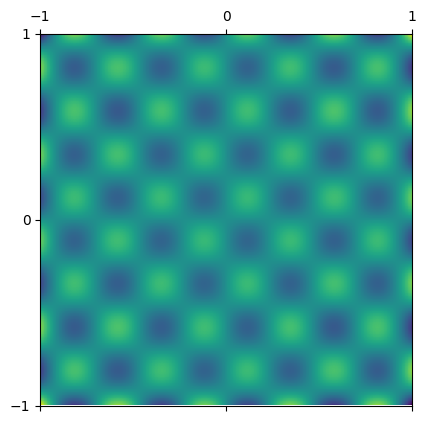

In [ ]:
show_waves(x, basis_set)

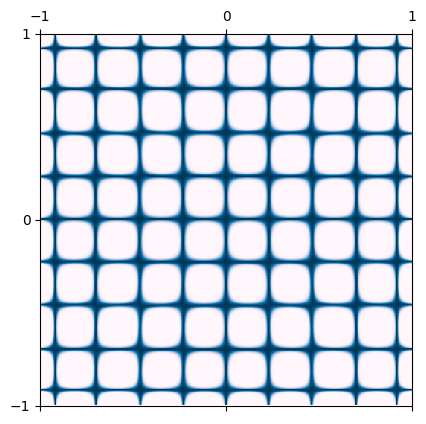

In [59]:
show_nodes(x, basis_set)